In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [3]:
# Main project path
PROJECT_PATH = r"C:\Users\abc\projects\Cancer Cell Classification Project"

# Subfolders
DATA_DIR = os.path.join(PROJECT_PATH, "Data")
FIGURES_DIR = os.path.join(PROJECT_PATH, "Figures")
NOTEBOOKS_DIR = os.path.join(PROJECT_PATH, "Notebooks")

# Create folders if they do not exist
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(NOTEBOOKS_DIR, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("NOTEBOOKS_DIR:", NOTEBOOKS_DIR)

DATA_DIR: C:\Users\abc\projects\Cancer Cell Classification Project\Data
FIGURES_DIR: C:\Users\abc\projects\Cancer Cell Classification Project\Figures
NOTEBOOKS_DIR: C:\Users\abc\projects\Cancer Cell Classification Project\Notebooks


In [5]:
X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
X_test = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_train = np.load(os.path.join(DATA_DIR, "y_train.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (630, 128, 128, 3)
X_test shape: (158, 128, 128, 3)
y_train shape: (630,)
y_test shape: (158,)


In [7]:
df = pd.read_csv(os.path.join(DATA_DIR, "expanded_dataset.csv"))

encoder = LabelEncoder()
encoder.fit(df["moa"])

class_names = list(encoder.classes_)
num_classes = len(class_names)

print("Encoded class order:")
for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

print("Number of classes:", num_classes)

Encoded class order:
0: Aurora kinase inhibitors
1: DNA damage
2: Eg5 inhibitors
3: Microtubule destabilizers
4: Microtubule stabilizers
Number of classes: 5


In [9]:
train_unique, train_counts = np.unique(y_train, return_counts=True)
test_unique, test_counts = np.unique(y_test, return_counts=True)

print("Training class distribution:")
for cls, count in zip(train_unique, train_counts):
    print(f"Class {cls} ({class_names[cls]}): {count}")

print("\nTest class distribution:")
for cls, count in zip(test_unique, test_counts):
    print(f"Class {cls} ({class_names[cls]}): {count}")

Training class distribution:
Class 0 (Aurora kinase inhibitors): 58
Class 1 (DNA damage): 86
Class 2 (Eg5 inhibitors): 67
Class 3 (Microtubule destabilizers): 112
Class 4 (Microtubule stabilizers): 307

Test class distribution:
Class 0 (Aurora kinase inhibitors): 14
Class 1 (DNA damage): 22
Class 2 (Eg5 inhibitors): 17
Class 3 (Microtubule destabilizers): 28
Class 4 (Microtubule stabilizers): 77


In [11]:
classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {int(cls): float(weight) for cls, weight in zip(classes, class_weights_array)}

print("Class weights:")
for cls, weight in class_weights.items():
    print(f"Class {cls} ({class_names[cls]}): {weight:.4f}")

Class weights:
Class 0 (Aurora kinase inhibitors): 2.1724
Class 1 (DNA damage): 1.4651
Class 2 (Eg5 inhibitors): 1.8806
Class 3 (Microtubule destabilizers): 1.1250
Class 4 (Microtubule stabilizers): 0.4104


In [13]:
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)

y_train_cat shape: (630, 5)
y_test_cat shape: (158, 5)


In [15]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.50),

    Dense(num_classes, activation='softmax')
])

model.summary()

C:\Users\abc\anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,933 (8.93 MB)

 Trainable params: 2,340,229 (8.93 MB)

 Non-trainable params: 704 (2.75 KB)

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [19]:
best_model_path = os.path.join(NOTEBOOKS_DIR, "best_cnn_moa_model.keras")

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=best_model_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, reduce_lr, model_checkpoint]

In [21]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.3448 - loss: 5.4310
Epoch 1: val_loss improved from inf to 5.75275, saving model to C:\Users\abc\projects\Cancer Cell Classification Project\Notebooks\best_cnn_moa_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 383ms/step - accuracy: 0.3471 - loss: 5.3949 - val_accuracy: 0.1508 - val_loss: 5.7528 - learning_rate: 0.0010
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.5501 - loss: 2.2255
Epoch 2: val_loss improved from 5.75275 to 4.19254, saving model to C:\Users\abc\projects\Cancer Cell Classification Project\Notebooks\best_cnn_moa_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 374ms/step - accuracy: 0.5509 - loss: 2.2149 - val_accuracy: 0.1508 - val_loss: 4.1925 - learning_rate: 0.0010
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.6157 - loss: 1.1190
Epoch 3: val_loss did not improve from 4.19254
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 341ms/step - accuracy: 0.6162 - loss: 1.1203 - val_accuracy: 0.1

In [23]:
final_model_path = os.path.join(NOTEBOOKS_DIR, "final_cnn_moa_model.keras")
model.save(final_model_path)

print("Best model saved to:", best_model_path)
print("Final model saved to:", final_model_path)

Best model saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Notebooks\best_cnn_moa_model.keras
Final model saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Notebooks\final_cnn_moa_model.keras


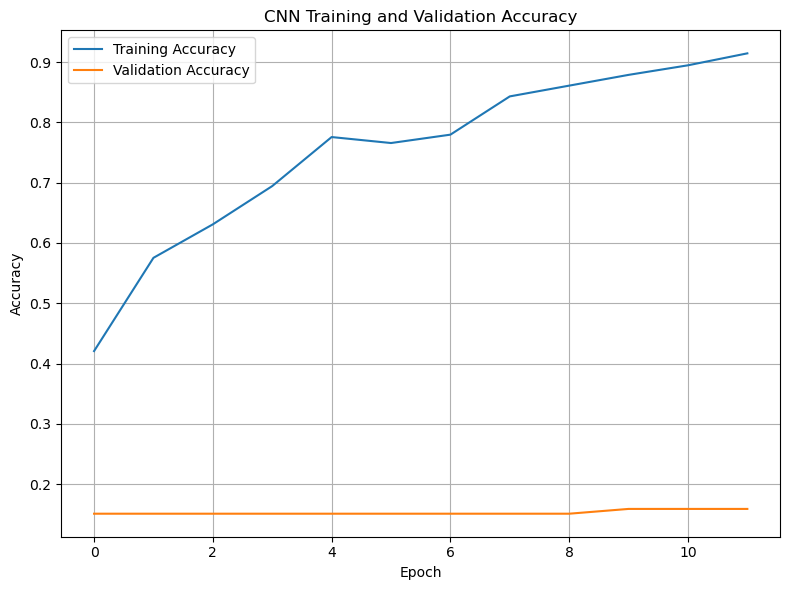

Figure saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\cnn_training_validation_accuracy.png


In [25]:
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()

accuracy_fig_path = os.path.join(FIGURES_DIR, "cnn_training_validation_accuracy.png")
plt.savefig(accuracy_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved to:", accuracy_fig_path)

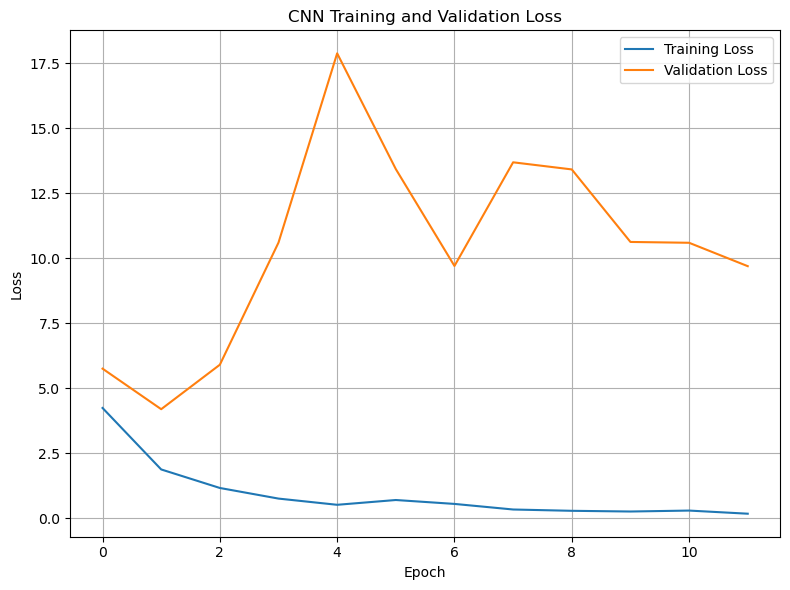

Figure saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\cnn_training_validation_loss.png


In [27]:
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_fig_path = os.path.join(FIGURES_DIR, "cnn_training_validation_loss.png")
plt.savefig(loss_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved to:", loss_fig_path)

In [29]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 4.6807
Test Accuracy: 0.1392


In [31]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Prediction complete.")
print("y_pred shape:", y_pred.shape)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step
Prediction complete.
y_pred shape: (158,)


In [33]:
test_acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")

Test Accuracy: 0.1392
Macro F1 Score: 0.0489


In [35]:
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

                           precision    recall  f1-score   support

 Aurora kinase inhibitors       0.00      0.00      0.00        14
               DNA damage       0.14      1.00      0.24        22
           Eg5 inhibitors       0.00      0.00      0.00        17
Microtubule destabilizers       0.00      0.00      0.00        28
  Microtubule stabilizers       0.00      0.00      0.00        77

                 accuracy                           0.14       158
                macro avg       0.03      0.20      0.05       158
             weighted avg       0.02      0.14      0.03       158



C:\Users\abc\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\abc\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\abc\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
report_path = os.path.join(FIGURES_DIR, "cnn_classification_report.txt")

with open(report_path, "w", encoding="utf-8") as f:
    f.write("CNN Classification Report\n")
    f.write("=========================\n\n")
    f.write(f"Test Loss: {test_loss:.4f}\n")
    f.write(f"Test Accuracy: {test_acc:.4f}\n")
    f.write(f"Macro F1 Score: {macro_f1:.4f}\n\n")
    f.write(report)

print("Classification report saved to:", report_path)

Classification report saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\cnn_classification_report.txt


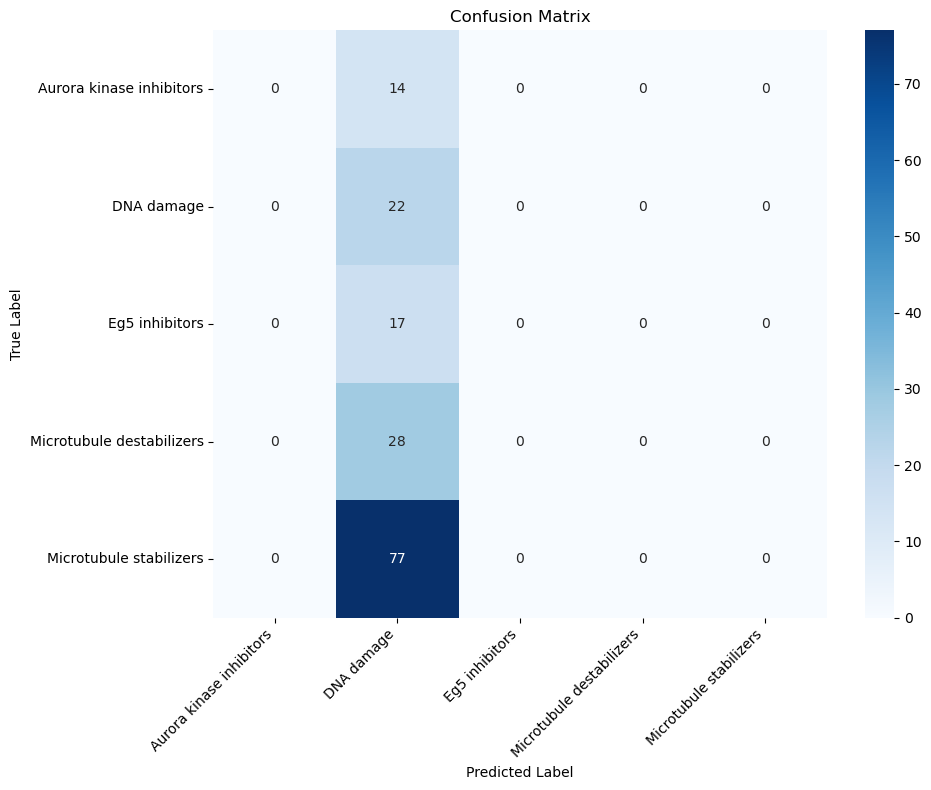

Figure saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\cnn_confusion_matrix.png


In [39]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

cm_fig_path = os.path.join(FIGURES_DIR, "cnn_confusion_matrix.png")
plt.savefig(cm_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved to:", cm_fig_path)

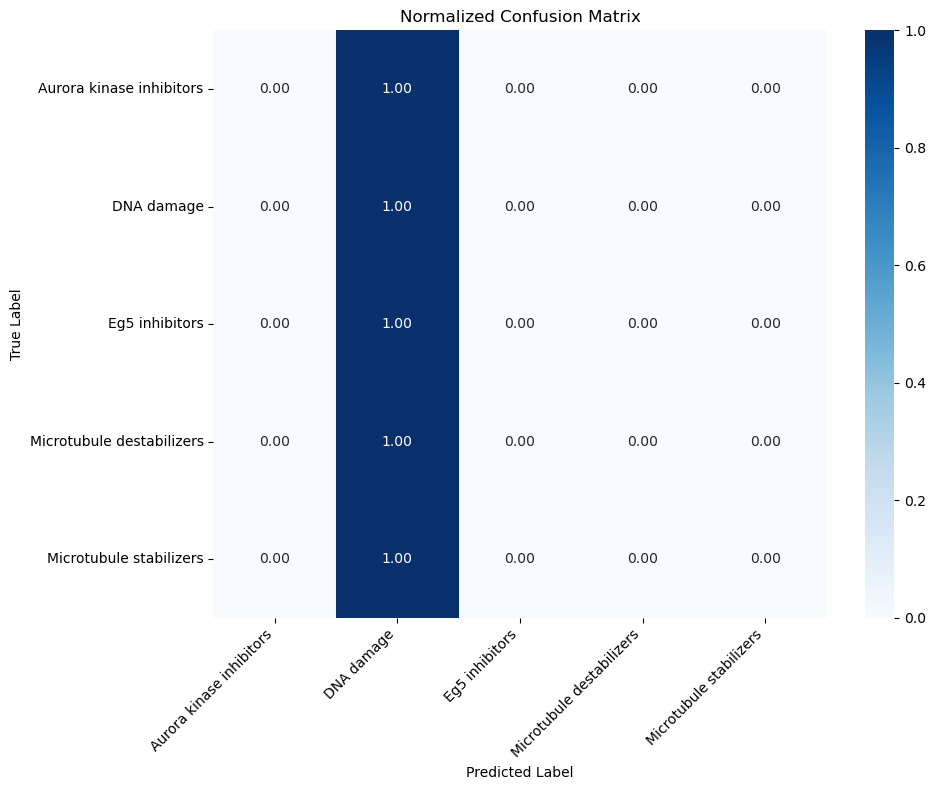

Figure saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\cnn_normalized_confusion_matrix.png


In [41]:
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

cm_norm_fig_path = os.path.join(FIGURES_DIR, "cnn_normalized_confusion_matrix.png")
plt.savefig(cm_norm_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved to:", cm_norm_fig_path)

In [43]:
summary_results_path = os.path.join(FIGURES_DIR, "cnn_evaluation_summary.txt")

with open(summary_results_path, "w", encoding="utf-8") as f:
    f.write("CNN Evaluation Summary\n")
    f.write("======================\n\n")
    f.write(f"Test Loss: {test_loss:.4f}\n")
    f.write(f"Test Accuracy: {test_acc:.4f}\n")
    f.write(f"Macro F1 Score: {macro_f1:.4f}\n")
    f.write(f"Number of Test Samples: {len(y_test)}\n")
    f.write(f"Number of Classes: {num_classes}\n\n")
    f.write("Class Names:\n")
    for i, name in enumerate(class_names):
        f.write(f"{i}: {name}\n")

print("Summary saved to:", summary_results_path)

Summary saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\cnn_evaluation_summary.txt
